In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv("Global_Pollution_Analysis.csv")

In [2]:
data.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [3]:
data.isnull()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False,False,False,False,False
196,False,False,False,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

In [6]:
from sklearn.model_selection import train_test_split

X = data.drop("Energy_Recovered (in GWh)", axis = 1)
y = data["Energy_Recovered (in GWh)"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state = 42)

In [7]:
X_train = pd.get_dummies(X_train, columns=['Country'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Country'], drop_first=True)

# Align columns (important if some countries missing in test)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
                 'CO2_Emissions (in MT)', 'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
                'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)', 'GDP_Per_Capita (in USD)']

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [9]:
data[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Industrial_Waste (in tons)",
    "CO2_Emissions (in MT)"
]].describe()

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),CO2_Emissions (in MT)
count,200.00000,200.000000,200.000000,200.00000,200.000000
mean,180.62695,115.068100,76.488550,52891.68150,24.878100
std,67.07331,47.580911,39.692727,27224.49169,14.470892
min,50.30000,31.130000,11.150000,1019.37000,1.920000
25%,134.97250,74.550000,40.895000,31201.97250,11.220000
50%,183.38500,112.305000,78.600000,55299.15000,25.355000
75%,237.42500,157.477500,109.212500,74805.82500,38.550000
max,297.95000,199.320000,149.230000,99739.36000,49.690000


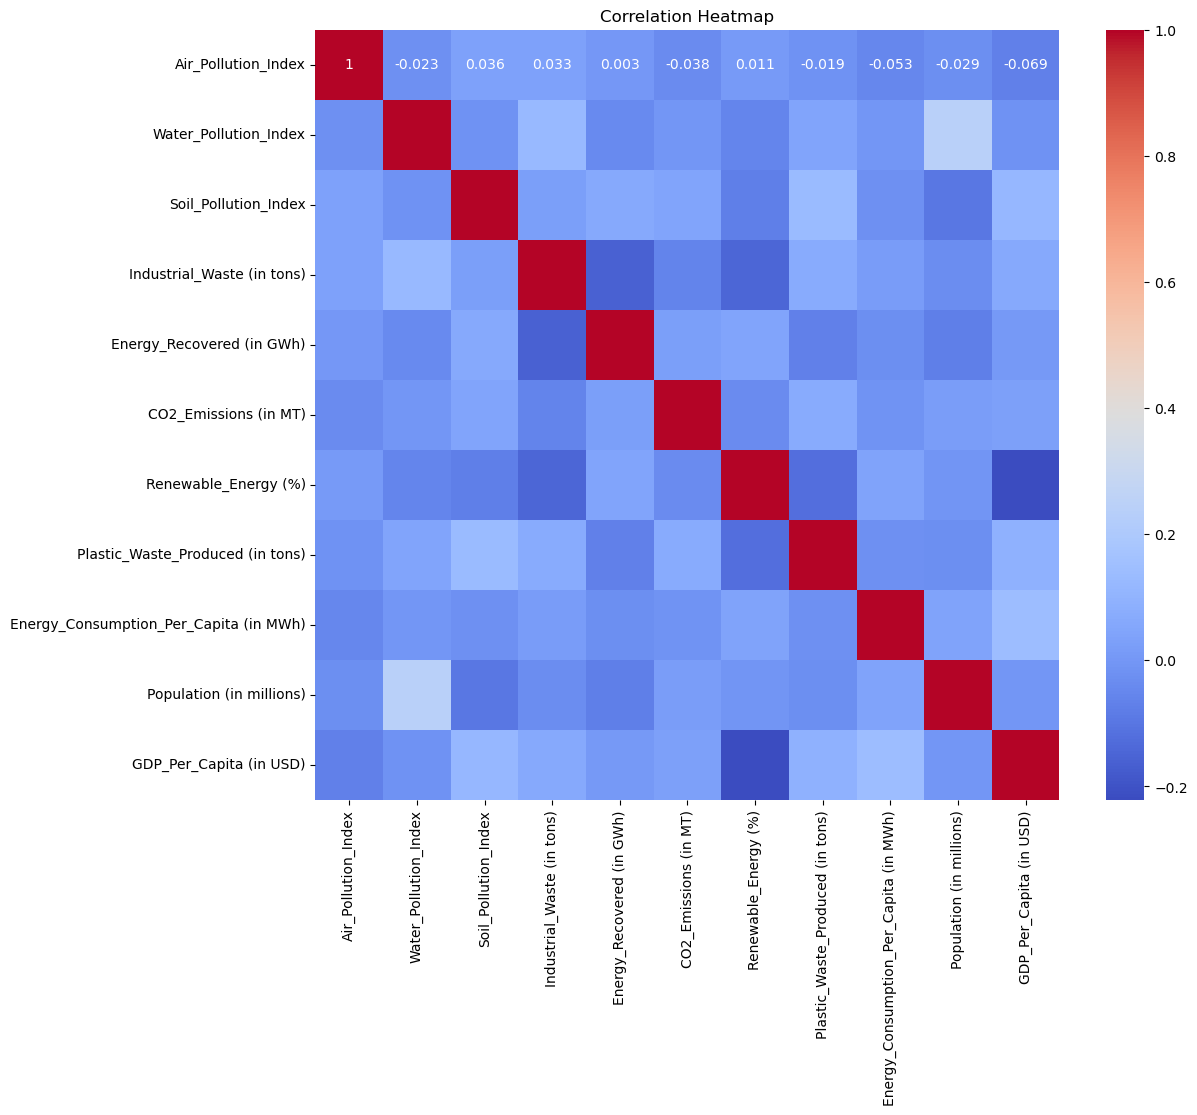

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(data.select_dtypes(include=['float64']).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
data.select_dtypes(include=['float64']).corr()["Energy_Recovered (in GWh)"].sort_values(ascending=False)

Energy_Recovered (in GWh)                 1.000000
Soil_Pollution_Index                      0.064076
Renewable_Energy (%)                      0.043533
CO2_Emissions (in MT)                     0.024758
GDP_Per_Capita (in USD)                   0.004535
Air_Pollution_Index                       0.002997
Energy_Consumption_Per_Capita (in MWh)   -0.030284
Water_Pollution_Index                    -0.041828
Plastic_Waste_Produced (in tons)         -0.072946
Population (in millions)                 -0.075100
Industrial_Waste (in tons)               -0.161309
Name: Energy_Recovered (in GWh), dtype: float64

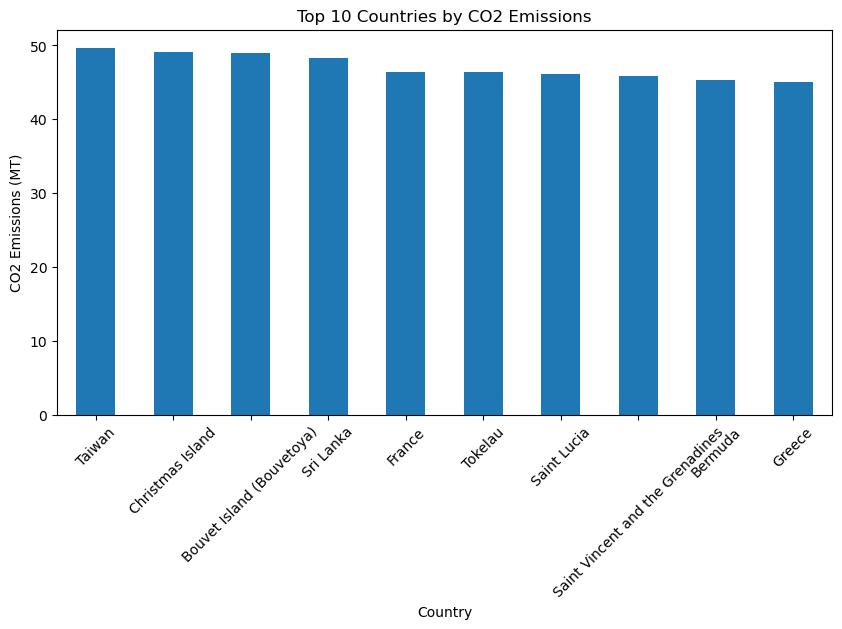

In [12]:
import matplotlib.pyplot as plt

top10_co2 = data.groupby("Country")["CO2_Emissions (in MT)"]\
    .mean().sort_values(ascending=False).head(10)

top10_co2.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Countries by CO2 Emissions")
plt.ylabel("CO2 Emissions (MT)")
plt.xticks(rotation=45)
plt.show()

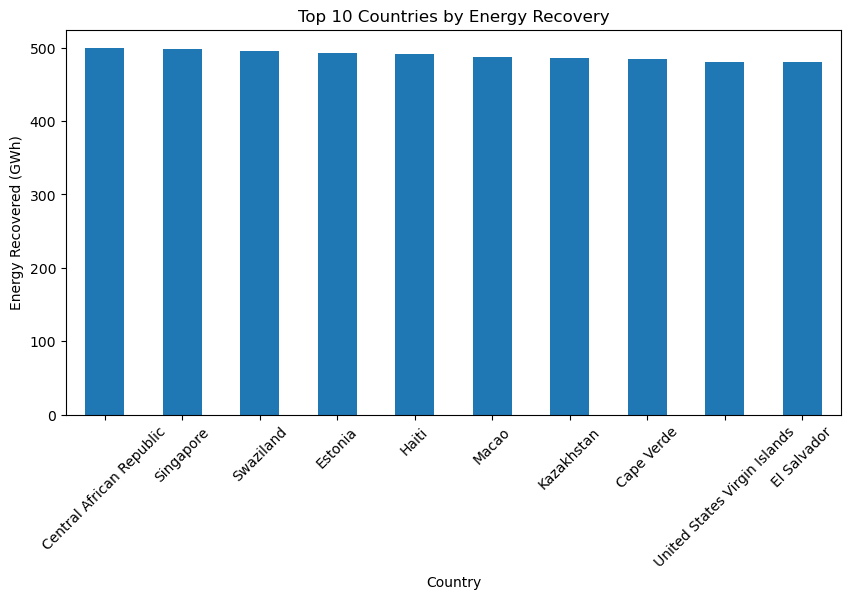

In [13]:
top10_energy = data.groupby("Country")["Energy_Recovered (in GWh)"]\
    .mean().sort_values(ascending=False).head(10)

top10_energy.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Countries by Energy Recovery")
plt.ylabel("Energy Recovered (GWh)")
plt.xticks(rotation=45)
plt.show()

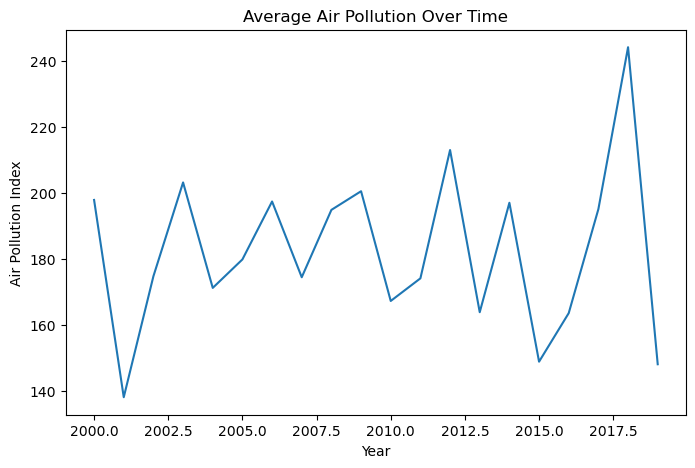

In [14]:
yearly_air = data.groupby("Year")["Air_Pollution_Index"].mean()

yearly_air.plot(figsize=(8,5))
plt.title("Average Air Pollution Over Time")
plt.ylabel("Air Pollution Index")
plt.show()

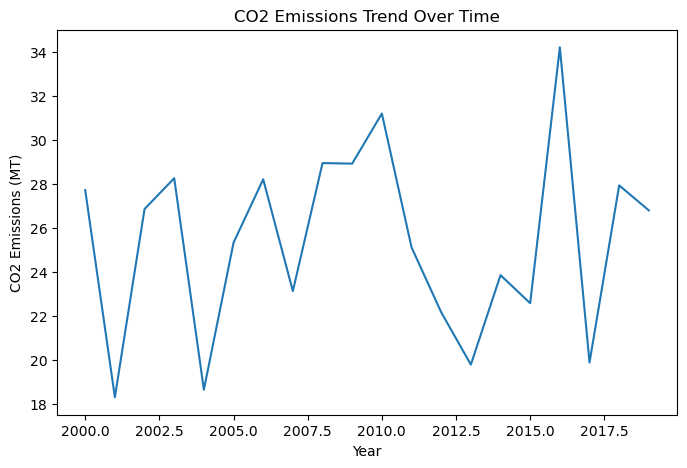

In [15]:
yearly_co2 = data.groupby("Year")["CO2_Emissions (in MT)"].mean()

yearly_co2.plot(figsize=(8,5))
plt.title("CO2 Emissions Trend Over Time")
plt.ylabel("CO2 Emissions (MT)")
plt.show()

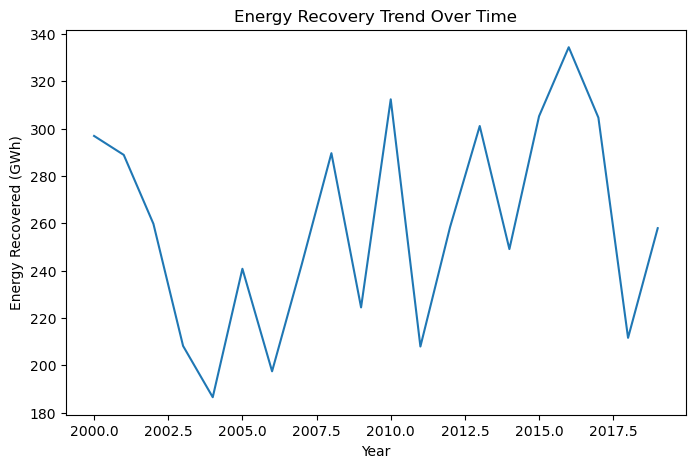

In [16]:
yearly_energy = data.groupby("Year")["Energy_Recovered (in GWh)"].mean()

yearly_energy.plot(figsize=(8,5))
plt.title("Energy Recovery Trend Over Time")
plt.ylabel("Energy Recovered (GWh)")
plt.show()

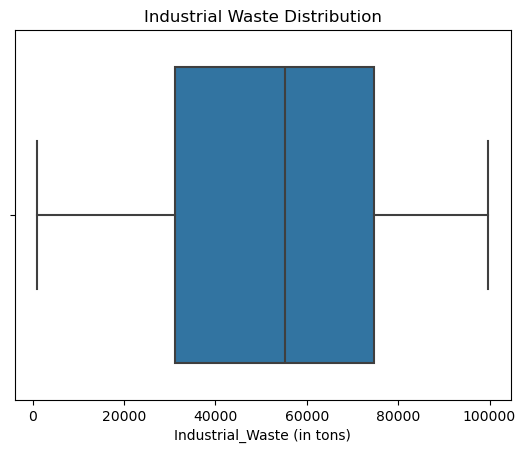

In [17]:
import seaborn as sns

sns.boxplot(x=data["Industrial_Waste (in tons)"])
plt.title("Industrial Waste Distribution")
plt.show()

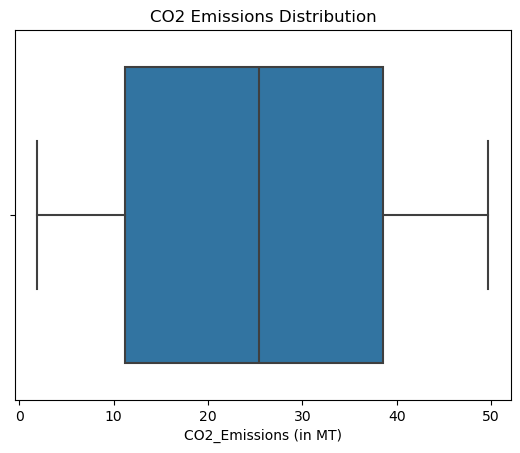

In [18]:
sns.boxplot(x=data["CO2_Emissions (in MT)"])
plt.title("CO2 Emissions Distribution")
plt.show()

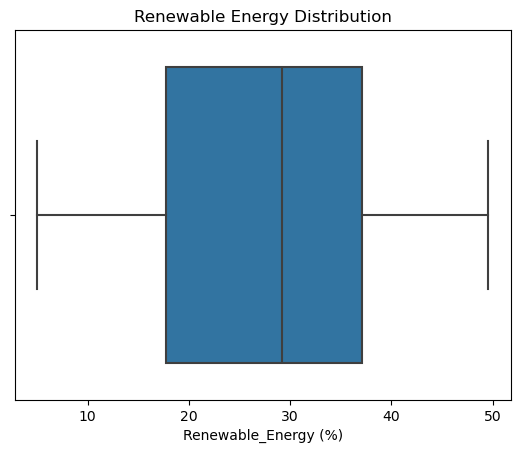

In [19]:
sns.boxplot(x=data["Renewable_Energy (%)"])
plt.title("Renewable Energy Distribution")
plt.show()

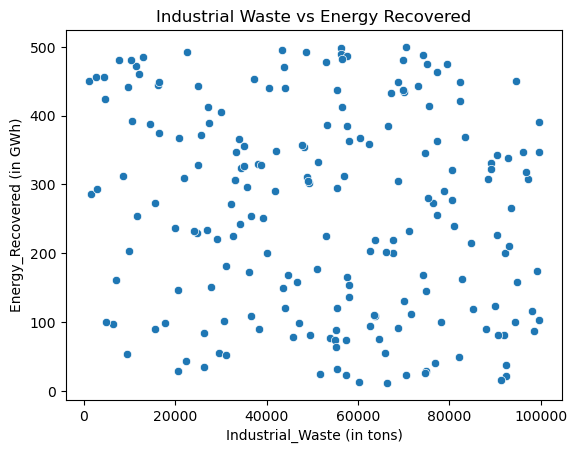

In [20]:
sns.scatterplot(
    x="Industrial_Waste (in tons)",
    y="Energy_Recovered (in GWh)",
    data=data
)
plt.title("Industrial Waste vs Energy Recovered")
plt.show()

In [21]:
data["Years_from_Start"] = data["Year"] - data["Year"].min()
yearly_trend = data.groupby("Year")[
    ["Air_Pollution_Index",
     "Water_Pollution_Index",
     "Soil_Pollution_Index",
     "Energy_Recovered (in GWh)"]
].mean()

print(yearly_trend)
data["Energy_Growth_Rate"] = data.groupby("Country")[
    "Energy_Recovered (in GWh)"
].pct_change()

      Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index  \
Year                                                                     
2000           197.796000             118.513000             69.283000   
2001           137.964444              83.933333             71.340000   
2002           174.661538             123.617692             75.344615   
2003           203.103000             133.080000            100.687000   
2004           171.120909             120.719091             69.959091   
2005           179.756000             108.245333             72.922000   
2006           197.326667             115.016667            100.613333   
2007           174.349091             107.464545             55.718182   
2008           194.782857             102.114286             75.508571   
2009           200.440000              99.040000             68.994000   
2010           167.158750             148.862500             96.501250   
2011           174.016154             

In [22]:
data["Energy_Consumption_Per_Capita (in MWh)"].describe()

count    200.00000
mean       9.43575
std        5.57567
min        0.53000
25%        4.58250
50%        9.22500
75%       13.99750
max       19.98000
Name: Energy_Consumption_Per_Capita (in MWh), dtype: float64

In [23]:
data["Estimated_Total_Energy"] = (
    data["Energy_Consumption_Per_Capita (in MWh)"] *
    data["Population (in millions)"]
)

In [24]:
y = data["Energy_Recovered (in GWh)"]
data = data.fillna(0)

X = data.drop(["Energy_Recovered (in GWh)", "Country"], axis=1)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

R² Score: -0.4830874468609432
MAE: 0.8292571281791696


In [27]:
data["Total_Pollution"] = (
    data["Air_Pollution_Index"] +
    data["Water_Pollution_Index"] +
    data["Soil_Pollution_Index"]
)
data["Pollution_Severity"] = pd.qcut(
    data["Total_Pollution"],
    q=3,
    labels=["Low", "Medium", "High"]
)
print(data["Pollution_Severity"].value_counts())

Pollution_Severity
Low       67
High      67
Medium    66
Name: count, dtype: int64


In [28]:
y = data["Pollution_Severity"]

X = data.drop([
    "Pollution_Severity",
    "Energy_Recovered (in GWh)",
    "Country"
], axis=1)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9
Accuracy: 0.9


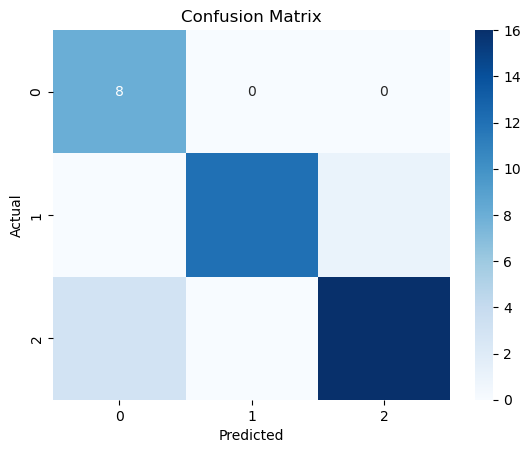

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()